# Results Tables & Charts
Reads `res/results.csv` and produces LaTeX tables (mean ± std across folds) and timing bar charts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../res/results.csv")

# Per-fold rows only (exclude pooled aggregate)
folds = df[df["fold"] != "pooled"].copy()
folds["fold"] = folds["fold"].astype(int)

# Consistent model order: simplest to largest
MODEL_ORDER = ["glm", "xgboost", "tabpfn", "tabpfn_2000", "tabpfn_5000", "tabpfn_10000", "tabpfn_50000", "tabpfn_100000"]

def mean_std_table(data, metric, index_col="model"):
    """Pivot mean±std LaTeX strings, rows ordered by MODEL_ORDER."""
    sub = data[data["metric"] == metric]
    stats = (
        sub.groupby(["dataset", index_col])["value"]
        .agg(["mean", "std"])
        .reset_index()
    )
    stats["mean_std"] = stats.apply(lambda r: f"{r['mean']:.4f} $\\pm$ {r['std']:.4f}", axis=1)
    table = stats.pivot(index=index_col, columns="dataset", values="mean_std")
    # Apply consistent row order, keeping only models present in the data
    order = [m for m in MODEL_ORDER if m in table.index]
    return table.loc[order]

## 1. Deviance table — Q1 Severity (Gamma deviance, lower is better)

In [2]:
sev = folds[folds["task"] == "sev"]
table_sev = mean_std_table(sev, "gamma_deviance")
print(table_sev.to_latex(
    escape=False,
    caption="Gamma deviance (mean $\\pm$ std over 5 folds) for severity models.",
    label="tab:severity"
))

\begin{table}
\caption{Gamma deviance (mean $\pm$ std over 5 folds) for severity models.}
\label{tab:severity}
\begin{tabular}{lll}
\toprule
dataset & beMTPL97 & freMTPL2 \\
model &  &  \\
\midrule
glm & 2.0463 $\pm$ 0.0668 & 1.7553 $\pm$ 0.2632 \\
xgboost & 2.0553 $\pm$ 0.0791 & 1.5976 $\pm$ 0.1408 \\
tabpfn & 3.7194 $\pm$ 0.2309 & 2.6419 $\pm$ 0.6175 \\
\bottomrule
\end{tabular}
\end{table}



## 2. Deviance table — Q2 Frequency (Poisson deviance, lower is better)

In [3]:
freq = folds[folds["task"] == "freq"]
table_freq = mean_std_table(freq, "poisson_deviance")
print(table_freq.to_latex(
    escape=False,
    caption="Poisson deviance (mean $\\pm$ std over 5 folds) for frequency models.",
    label="tab:frequency"
))

\begin{table}
\caption{Poisson deviance (mean $\pm$ std over 5 folds) for frequency models.}
\label{tab:frequency}
\begin{tabular}{lll}
\toprule
dataset & beMTPL97 & freMTPL2 \\
model &  &  \\
\midrule
glm & 0.5508 $\pm$ 0.0041 & 0.2961 $\pm$ 0.0011 \\
xgboost & 0.5829 $\pm$ 0.0041 & 0.3441 $\pm$ 0.0007 \\
tabpfn_2000 & 0.5847 $\pm$ 0.0091 & 0.4524 $\pm$ 0.2400 \\
tabpfn_5000 & 0.5885 $\pm$ 0.0140 & 0.4947 $\pm$ 0.1237 \\
tabpfn_10000 & 0.5834 $\pm$ 0.0195 & 0.5679 $\pm$ 0.1360 \\
tabpfn_50000 & 0.5642 $\pm$ 0.0115 & 0.4786 $\pm$ 0.0861 \\
tabpfn_100000 & 0.5558 $\pm$ 0.0049 & 0.4289 $\pm$ 0.0698 \\
\bottomrule
\end{tabular}
\end{table}



## 3. Combined frequency + severity table

In [4]:
def mean_std_series(data, metric):
    """Return a Series indexed by model with mean±std strings."""
    sub = data[data["metric"] == metric]
    stats = sub.groupby("model")["value"].agg(["mean", "std"])
    return stats.apply(lambda r: f"{r['mean']:.3f} $\\pm$ {r['std']:.3f}", axis=1)

datasets = ["freMTPL2", "beMTPL97"]
task_metric = [("freq", "poisson_deviance"), ("sev", "gamma_deviance")]

cols = {}
for dataset in datasets:
    sub_ds = folds[folds["dataset"] == dataset]
    for task, metric in task_metric:
        sub_task = sub_ds[sub_ds["task"] == task]
        cols[(dataset, task)] = mean_std_series(sub_task, metric)

combined = pd.DataFrame(cols)
combined.columns = pd.MultiIndex.from_tuples(combined.columns, names=["Dataset", "Task"])

# Consistent row order
order = [m for m in MODEL_ORDER if m in combined.index]
combined = combined.loc[order]

print(combined.to_latex(
    escape=False,
    caption="Poisson deviance (frequency) and Gamma deviance (severity), mean $\\pm$ std over 5 folds.",
    label="tab:combined"
))

\begin{table}
\caption{Poisson deviance (frequency) and Gamma deviance (severity), mean $\pm$ std over 5 folds.}
\label{tab:combined}
\begin{tabular}{lllll}
\toprule
Dataset & \multicolumn{2}{r}{freMTPL2} & \multicolumn{2}{r}{beMTPL97} \\
Task & freq & sev & freq & sev \\
model &  &  &  &  \\
\midrule
glm & 0.296 $\pm$ 0.001 & 1.755 $\pm$ 0.263 & 0.551 $\pm$ 0.004 & 2.046 $\pm$ 0.067 \\
xgboost & 0.344 $\pm$ 0.001 & 1.598 $\pm$ 0.141 & 0.583 $\pm$ 0.004 & 2.055 $\pm$ 0.079 \\
tabpfn & NaN & 2.642 $\pm$ 0.617 & NaN & 3.719 $\pm$ 0.231 \\
tabpfn_2000 & 0.452 $\pm$ 0.240 & NaN & 0.585 $\pm$ 0.009 & NaN \\
tabpfn_5000 & 0.495 $\pm$ 0.124 & NaN & 0.589 $\pm$ 0.014 & NaN \\
tabpfn_10000 & 0.568 $\pm$ 0.136 & NaN & 0.583 $\pm$ 0.019 & NaN \\
tabpfn_50000 & 0.479 $\pm$ 0.086 & NaN & 0.564 $\pm$ 0.011 & NaN \\
tabpfn_100000 & 0.429 $\pm$ 0.070 & NaN & 0.556 $\pm$ 0.005 & NaN \\
\bottomrule
\end{tabular}
\end{table}



## 4. Timing bar charts — fit+predict time per dataset (scalability)

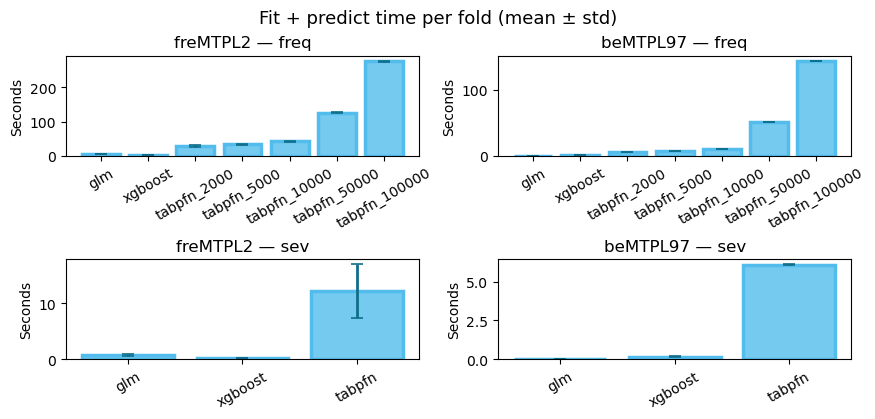

Saved to res/timing_barchart.pdf


In [5]:
timing = folds[folds["metric"] == "fit_predict_seconds"]

timing_stats = (
    timing.groupby(["dataset", "task", "model"])["value"]
    .agg(["mean", "std"])
    .reset_index()
)

tasks = ["freq", "sev"]

bar_outline = "#52BDEC"
bar_fill = (82 / 255, 189 / 255, 236 / 255, 0.8)
whisker_color = "#116E8A"
fig_width_in = 7.2*1.2
fig_height_in = 3.4*1.2

fig, axes = plt.subplots(
    len(tasks),
    len(datasets),
    figsize=(fig_width_in, fig_height_in),
    squeeze=False,
    constrained_layout=True,
)

for row, task in enumerate(tasks):
    for col, dataset in enumerate(datasets):
        ax = axes[row][col]
        sub = timing_stats[(timing_stats["task"] == task) & (timing_stats["dataset"] == dataset)].copy()
        if sub.empty:
            ax.set_visible(False)
            continue
        # Apply consistent model order
        sub["model"] = pd.Categorical(sub["model"], categories=[m for m in MODEL_ORDER if m in sub["model"].values], ordered=True)
        sub = sub.sort_values("model")
        ax.bar(
            sub["model"],
            sub["mean"],
            yerr=sub["std"],
            capsize=4,
            color=bar_fill,
            edgecolor=bar_outline,
            linewidth=2.5,
            error_kw={"ecolor": whisker_color, "elinewidth": 2, "capthick": 1.2},
        )
        ax.set_title(f"{dataset} — {task}")
        ax.set_ylabel("Seconds")
        ax.tick_params(axis="x", rotation=30)

fig.suptitle("Fit + predict time per fold (mean ± std)", fontsize=13)
fig.savefig("../res/timing_barchart.pdf", bbox_inches="tight")
plt.show()
print("Saved to res/timing_barchart.pdf")

## 5. Pooled deviance table (single aggregate score)

In [6]:
pooled = df[df["fold"] == "pooled"].copy()
pooled_dev = pooled[pooled["metric"].isin(["gamma_deviance", "poisson_deviance"])]

table_pooled = pooled_dev.pivot_table(index="model", columns=["dataset", "task"], values="value")
order = [m for m in MODEL_ORDER if m in table_pooled.index]
table_pooled = table_pooled.loc[order]

print(table_pooled.round(4).to_latex(
    caption="Pooled out-of-fold deviance.",
    label="tab:pooled"
))

\begin{table}
\caption{Pooled out-of-fold deviance.}
\label{tab:pooled}
\begin{tabular}{lrrrr}
\toprule
dataset & \multicolumn{2}{r}{beMTPL97} & \multicolumn{2}{r}{freMTPL2} \\
task & freq & sev & freq & sev \\
model &  &  &  &  \\
\midrule
glm & 0.550800 & 2.046400 & 0.296100 & 1.755300 \\
xgboost & 0.582900 & 2.055500 & 0.344100 & 1.597500 \\
tabpfn & NaN & 3.719900 & NaN & 2.641800 \\
\bottomrule
\end{tabular}
\end{table}



## 6. Per-fold deviance line plots

/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_4755/1067369150.py:70: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.07, 1, 1])  # leave space for suptitle and legend


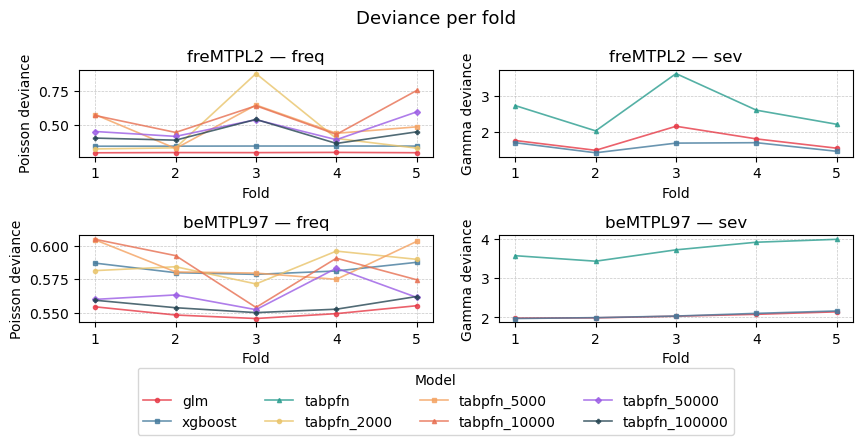

Saved to res/per_fold_lines.pdf


In [24]:
# Assign a colour and marker to each model (consistent across all subplots)
MODEL_STYLES = {
    "glm":          {"color": "#E63946", "marker": "o", "ls": "-"},
    "xgboost":      {"color": "#457B9D", "marker": "s", "ls": "-"},
    "tabpfn":       {"color": "#2A9D8F", "marker": "^", "ls": "-"},
    "tabpfn_2000":  {"color": "#E9C46A", "marker": "o", "ls": "-"},
    "tabpfn_5000":  {"color": "#F4A261", "marker": "s", "ls": "-"},
    "tabpfn_10000": {"color": "#E76F51", "marker": "^", "ls": "-"},
    "tabpfn_50000": {"color": "#9B5DE5", "marker": "D", "ls": "-"},
    "tabpfn_100000":{"color": "#264653", "marker": "P", "ls": "-"},
}

TASK_METRIC = {"freq": "poisson_deviance", "sev": "gamma_deviance"}
TASK_LABEL  = {"freq": "Poisson deviance", "sev": "Gamma deviance"}
tasks    = ["freq", "sev"]
datasets = ["freMTPL2", "beMTPL97"]

fig_width_in = 7.2*1.2
fig_height_in = 3.4*1.2

fig, axes = plt.subplots(
    len(datasets), len(tasks),
    figsize=(fig_width_in, fig_height_in),
    squeeze=False,
    constrained_layout=True,
)

handles_labels = {}  # collect legend entries

for row, dataset in enumerate(datasets):
    for col, task in enumerate(tasks):
        ax = axes[row][col]
        metric = TASK_METRIC[task]

        sub = folds[
            (folds["dataset"] == dataset) &
            (folds["task"]    == task)    &
            (folds["metric"]  == metric)
        ]

        models_present = [m for m in MODEL_ORDER if m in sub["model"].values]
        for model in models_present:
            model_data = sub[sub["model"] == model].sort_values("fold")
            style = MODEL_STYLES.get(model, {"color": "grey", "marker": "o", "ls": "-"})
            line, = ax.plot(
                model_data["fold"] + 1,  # show as 1-based fold index
                model_data["value"],
                color=style["color"], marker=style["marker"], ls=style["ls"],
                linewidth=1.2, markersize=3, label=model,
                alpha=0.8,
            )
            handles_labels[model] = line

        ax.set_title(f"{dataset} — {task}")
        ax.set_xlabel("Fold")
        ax.set_ylabel(TASK_LABEL[task])
        ax.set_xticks(range(1, len(folds["fold"].unique()) + 1))
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# Shared legend below the figure
ordered_handles = [handles_labels[m] for m in MODEL_ORDER if m in handles_labels]
ordered_labels  = [m for m in MODEL_ORDER if m in handles_labels]
fig.legend(
    ordered_handles, ordered_labels,
    loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.08),
    title="Model", frameon=True,
)

fig.suptitle("Deviance per fold", fontsize=13)
plt.tight_layout(rect=[0, 0.07, 1, 1])  # leave space for suptitle and legend
fig.savefig("../res/per_fold_lines.pdf", bbox_inches="tight")
plt.show()
print("Saved to res/per_fold_lines.pdf")
